In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler, Normalizer, RobustScaler

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, make_scorer, roc_curve, roc_auc_score

from sklearn.base import BaseEstimator, TransformerMixin

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import NearMiss

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [2]:
random_state = 42

df = pd.read_csv('~/Projeto/Portfolio/Portfolio2/Churn/data/telco.csv')


In [34]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [35]:
# ------------------------------------------------
# DROP DE VARIÁVEIS
# ------------------------------------------------

cols_to_drop = [
    "Customer ID",
    "Customer Status",
    "Churn Label",
    "Churn Score",
    "Churn Category",
    "Churn Reason",
    "CLTV",
    "Zip Code",
    "Latitude",
    "Longitude",
    "Country",
    "State",
    "City"
]


In [36]:
# ------------------------------------------------
# TARGET
# ------------------------------------------------

y = (df["Churn Label"] == "Yes").astype(int)
X = df.drop(columns=cols_to_drop)

# ------------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

# ------------------------------------------------
# CLIPPER DE OUTLIERS
# ------------------------------------------------

class QuantileClipper(BaseEstimator, TransformerMixin):

    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.q_low_ = X.quantile(self.lower)
        self.q_high_ = X.quantile(self.upper)
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.clip(self.q_low_, self.q_high_, axis=1)

In [37]:
# ------------------------------------------------
# FEATURES
# ------------------------------------------------

num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

# ------------------------------------------------
# NUMERIC PIPELINE
# ------------------------------------------------

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clipper', QuantileClipper(0.01,0.99))
])

# ------------------------------------------------
# CATEGORICAL PIPELINE
# ------------------------------------------------

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ------------------------------------------------
# PREPROCESSOR
# ------------------------------------------------

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# ------------------------------------------------
# SCALERS
# ------------------------------------------------

scalers = {
    "None": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
    "Normalizer": Normalizer()
}

# ------------------------------------------------
# MODELS
# ------------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=random_state
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=random_state
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=random_state
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        random_state=random_state
    ),

    "LightGBM": LGBMClassifier(
        random_state=random_state
    ),

    "XGBoost": XGBClassifier(
        random_state=random_state,
        eval_metric="logloss"
    )
}


Scaler: None | Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1035
           1       0.78      0.92      0.85       374

    accuracy                           0.91      1409
   macro avg       0.88      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409



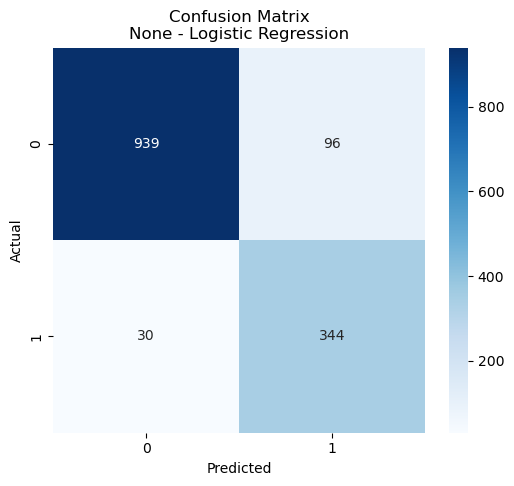


Scaler: None | Model: Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1035
           1       0.79      0.94      0.86       374

    accuracy                           0.92      1409
   macro avg       0.88      0.92      0.90      1409
weighted avg       0.93      0.92      0.92      1409



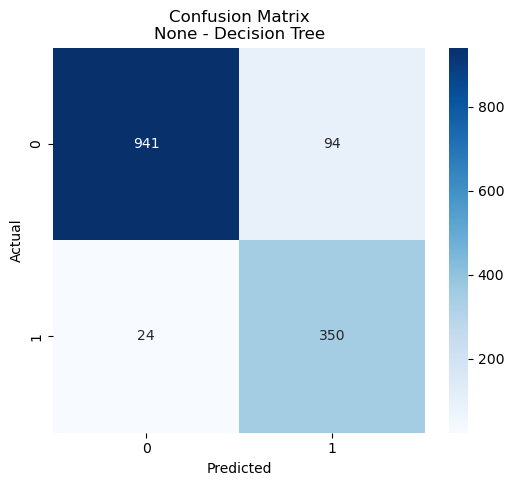


Scaler: None | Model: Random Forest
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1035
           1       0.77      0.93      0.84       374

    accuracy                           0.91      1409
   macro avg       0.87      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409



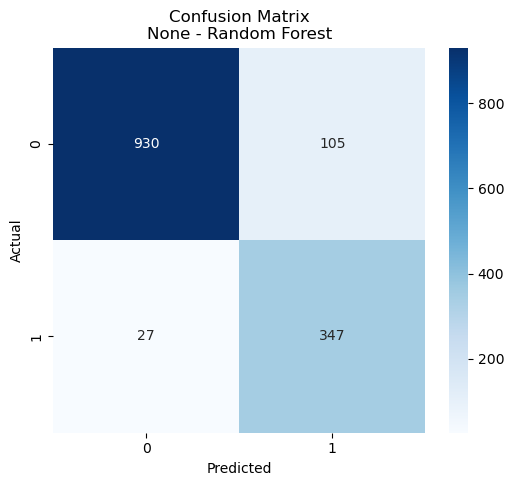


Scaler: None | Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1035
           1       0.77      0.94      0.85       374

    accuracy                           0.91      1409
   macro avg       0.87      0.92      0.89      1409
weighted avg       0.92      0.91      0.91      1409



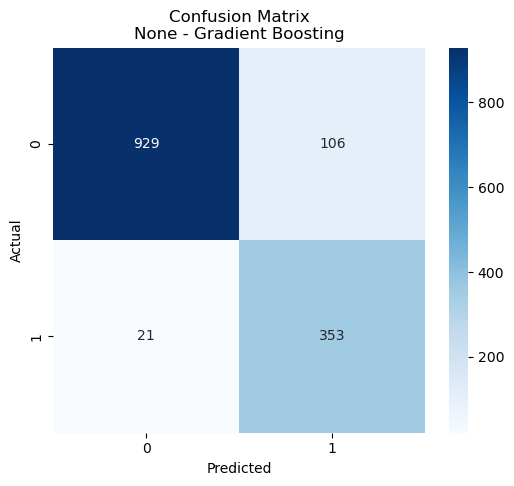

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1890
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1885
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[Lig

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1892
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing row-wise multi-threading

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha


Scaler: None | Model: LightGBM
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1035
           1       0.80      0.95      0.86       374

    accuracy                           0.92      1409
   macro avg       0.89      0.93      0.90      1409
weighted avg       0.93      0.92      0.92      1409



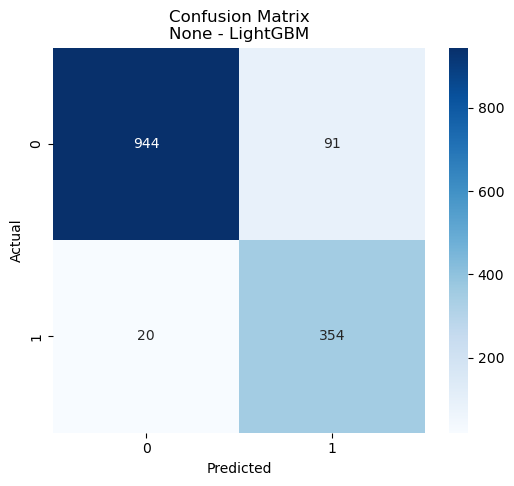


Scaler: None | Model: XGBoost
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1035
           1       0.74      0.95      0.83       374

    accuracy                           0.90      1409
   macro avg       0.86      0.91      0.88      1409
weighted avg       0.92      0.90      0.90      1409



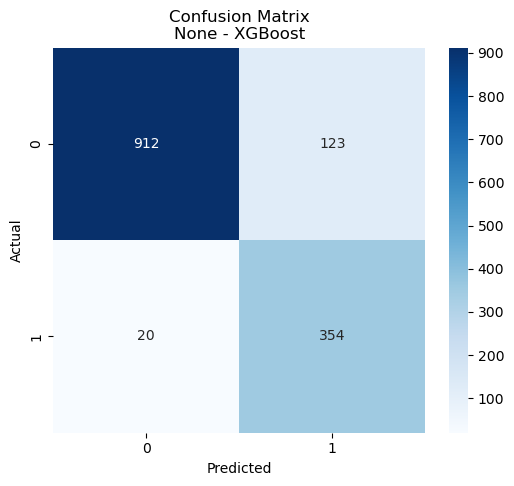


Scaler: StandardScaler | Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1035
           1       0.81      0.94      0.87       374

    accuracy                           0.93      1409
   macro avg       0.89      0.93      0.91      1409
weighted avg       0.93      0.93      0.93      1409



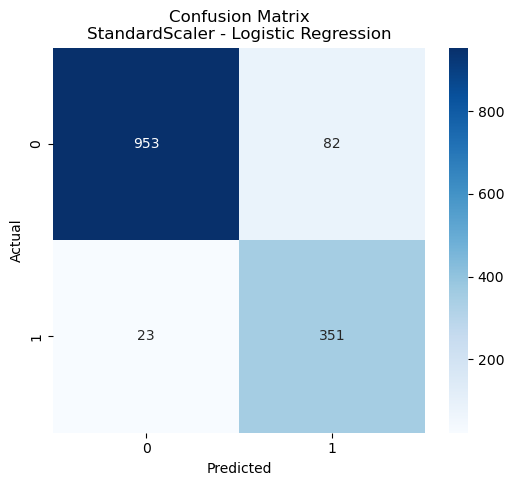


Scaler: StandardScaler | Model: Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1035
           1       0.79      0.94      0.86       374

    accuracy                           0.92      1409
   macro avg       0.88      0.92      0.90      1409
weighted avg       0.93      0.92      0.92      1409



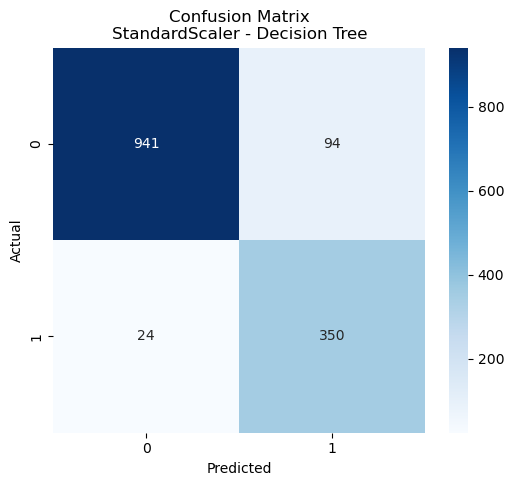


Scaler: StandardScaler | Model: Random Forest
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1035
           1       0.77      0.93      0.84       374

    accuracy                           0.91      1409
   macro avg       0.87      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409



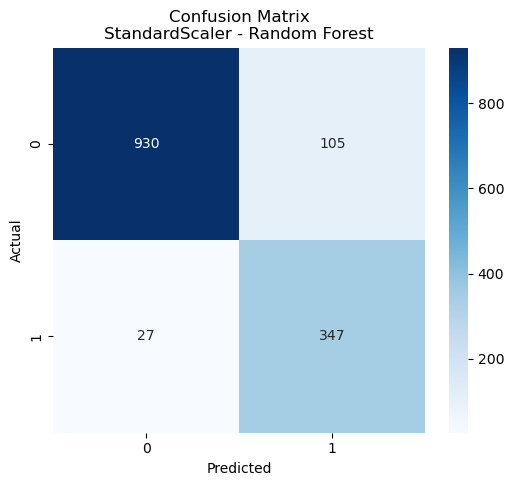


Scaler: StandardScaler | Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1035
           1       0.77      0.94      0.85       374

    accuracy                           0.91      1409
   macro avg       0.87      0.92      0.89      1409
weighted avg       0.92      0.91      0.91      1409



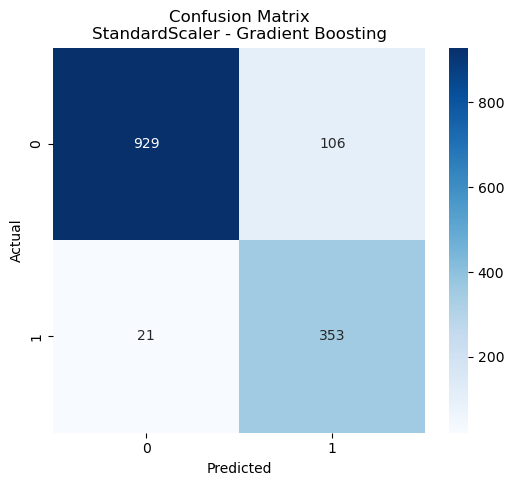

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000197 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1946
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1941
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[Lig

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1948
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1948
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1495, number of negative: 1495
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1958
[LightGBM] [Info] Number of data points in the train set: 2990, number of used features: 64
[Lig

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


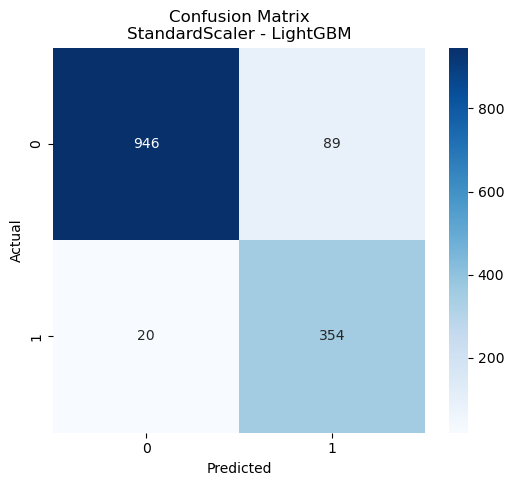


Scaler: StandardScaler | Model: XGBoost
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1035
           1       0.74      0.95      0.83       374

    accuracy                           0.90      1409
   macro avg       0.86      0.91      0.88      1409
weighted avg       0.92      0.90      0.90      1409



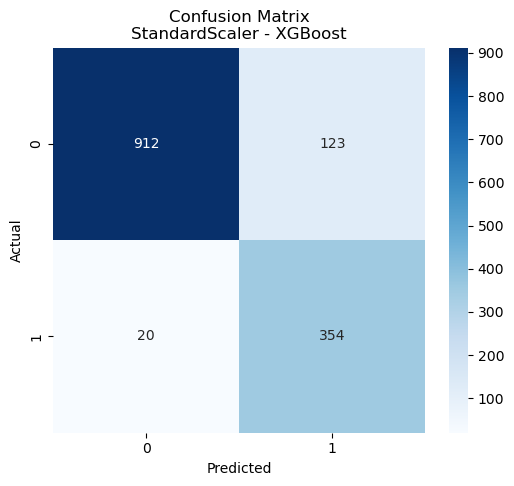


Scaler: MinMaxScaler | Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      1035
           1       0.82      0.93      0.87       374

    accuracy                           0.93      1409
   macro avg       0.90      0.93      0.91      1409
weighted avg       0.93      0.93      0.93      1409



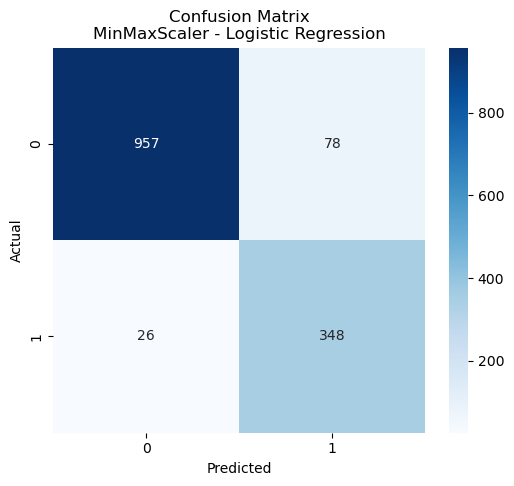


Scaler: MinMaxScaler | Model: Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1035
           1       0.79      0.94      0.86       374

    accuracy                           0.92      1409
   macro avg       0.88      0.92      0.90      1409
weighted avg       0.93      0.92      0.92      1409



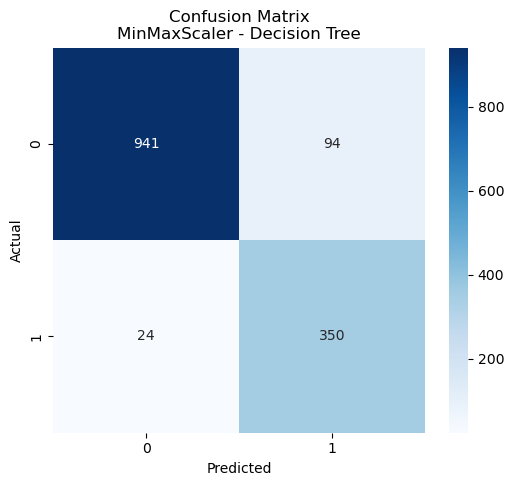


Scaler: MinMaxScaler | Model: Random Forest
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1035
           1       0.77      0.93      0.84       374

    accuracy                           0.91      1409
   macro avg       0.87      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409



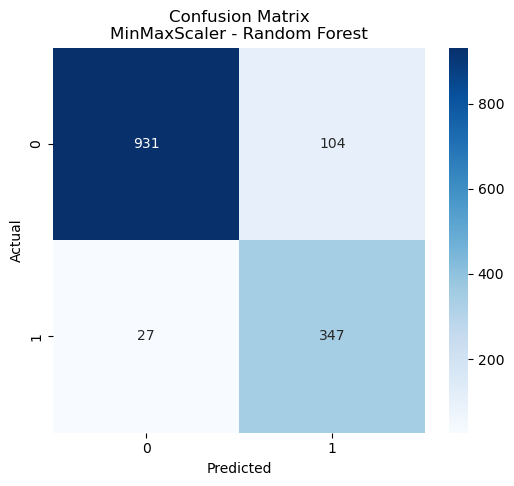


Scaler: MinMaxScaler | Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1035
           1       0.77      0.94      0.85       374

    accuracy                           0.91      1409
   macro avg       0.87      0.92      0.89      1409
weighted avg       0.92      0.91      0.91      1409



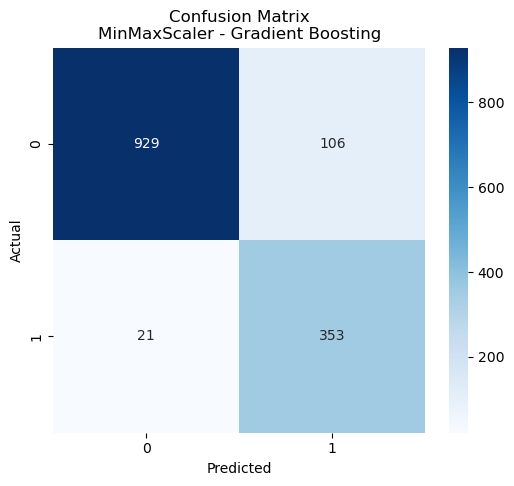

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1887
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1882
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive 

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1886
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1889
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1890
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1495, number of negative: 1495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000451 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1898
[LightGBM] [Info] Number of data points in the train set: 2990, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


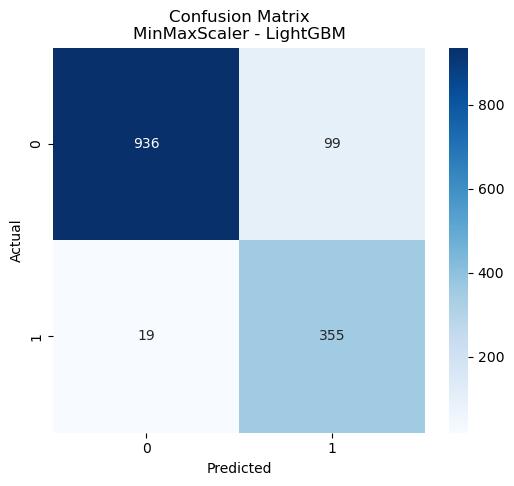


Scaler: MinMaxScaler | Model: XGBoost
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1035
           1       0.74      0.95      0.83       374

    accuracy                           0.90      1409
   macro avg       0.86      0.91      0.88      1409
weighted avg       0.92      0.90      0.90      1409



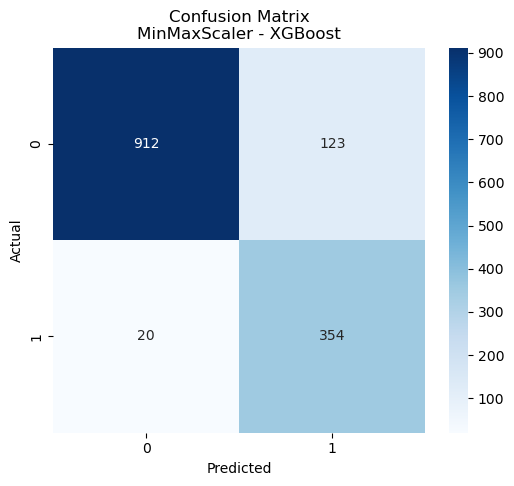


Scaler: RobustScaler | Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1035
           1       0.81      0.94      0.87       374

    accuracy                           0.93      1409
   macro avg       0.89      0.93      0.91      1409
weighted avg       0.93      0.93      0.93      1409



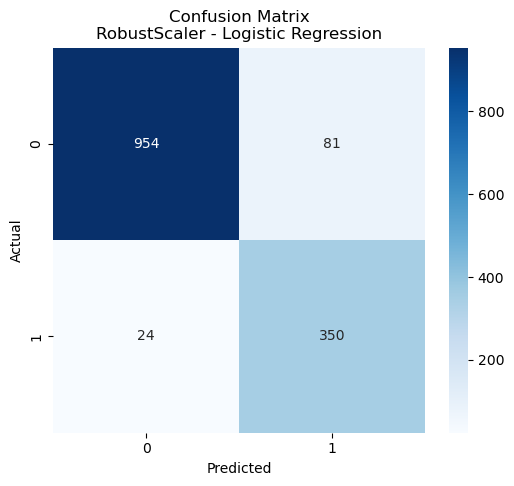


Scaler: RobustScaler | Model: Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1035
           1       0.79      0.94      0.86       374

    accuracy                           0.92      1409
   macro avg       0.88      0.92      0.90      1409
weighted avg       0.93      0.92      0.92      1409



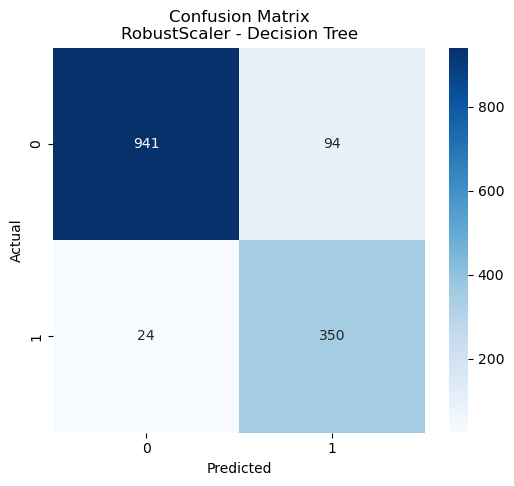


Scaler: RobustScaler | Model: Random Forest
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1035
           1       0.77      0.93      0.84       374

    accuracy                           0.91      1409
   macro avg       0.87      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409



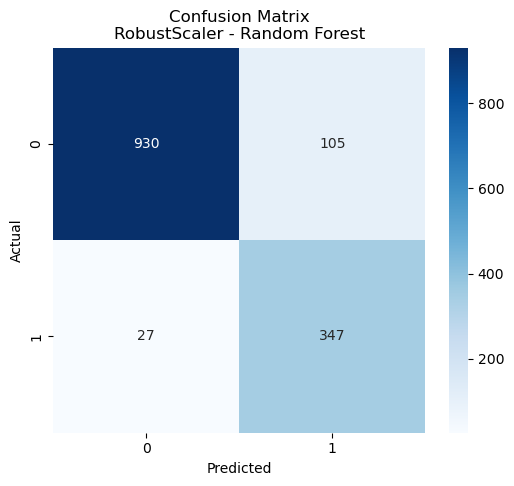


Scaler: RobustScaler | Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1035
           1       0.77      0.94      0.85       374

    accuracy                           0.91      1409
   macro avg       0.87      0.92      0.89      1409
weighted avg       0.92      0.91      0.91      1409



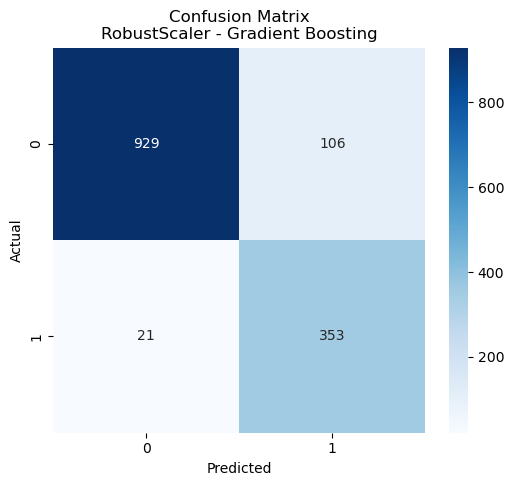

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000585 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000598 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1883
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive 

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000589 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1886
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1889
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive 

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1891
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1495, number of negative: 1495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000648 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1899
[LightGBM] [Info] Number of data points in the train set: 2990, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


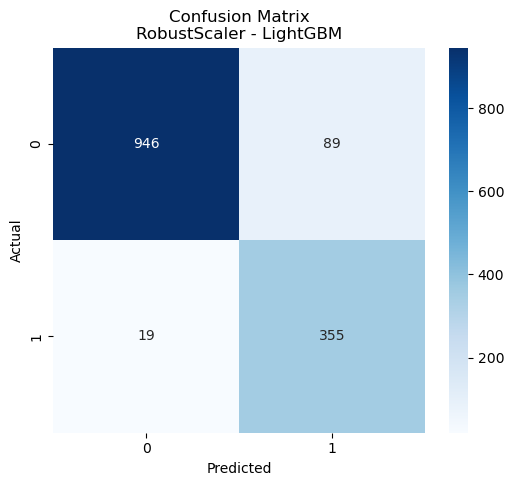


Scaler: RobustScaler | Model: XGBoost
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1035
           1       0.74      0.95      0.83       374

    accuracy                           0.90      1409
   macro avg       0.86      0.91      0.88      1409
weighted avg       0.92      0.90      0.90      1409



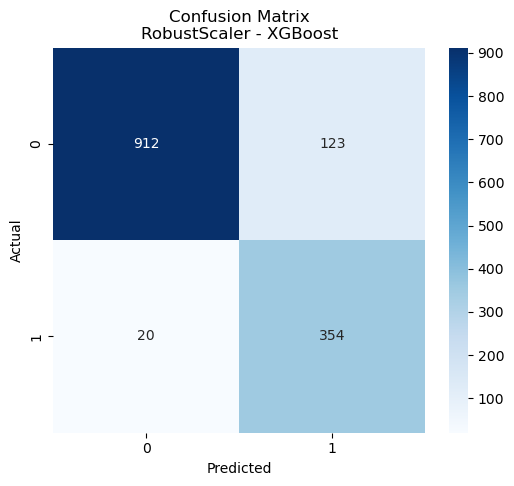


Scaler: MaxAbsScaler | Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      1035
           1       0.81      0.93      0.87       374

    accuracy                           0.92      1409
   macro avg       0.89      0.93      0.91      1409
weighted avg       0.93      0.92      0.93      1409



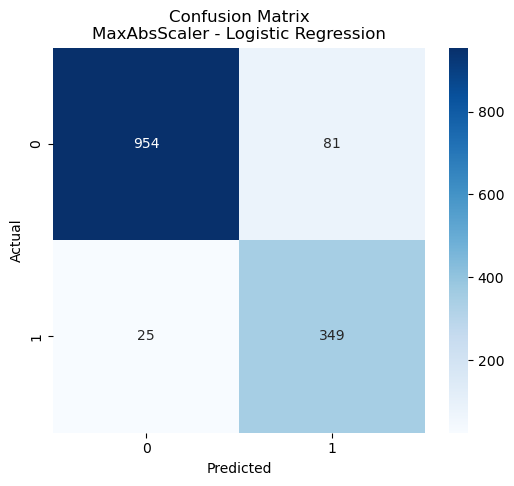


Scaler: MaxAbsScaler | Model: Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1035
           1       0.79      0.94      0.86       374

    accuracy                           0.92      1409
   macro avg       0.88      0.92      0.90      1409
weighted avg       0.93      0.92      0.92      1409



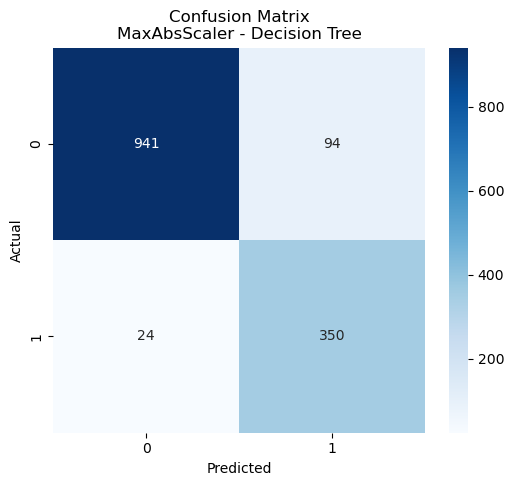


Scaler: MaxAbsScaler | Model: Random Forest
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1035
           1       0.77      0.93      0.84       374

    accuracy                           0.91      1409
   macro avg       0.87      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409



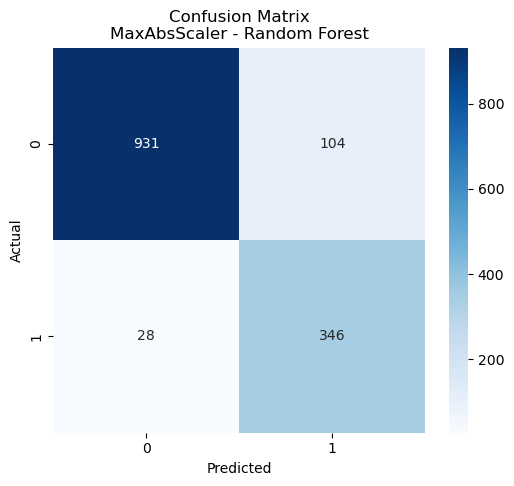


Scaler: MaxAbsScaler | Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1035
           1       0.77      0.94      0.85       374

    accuracy                           0.91      1409
   macro avg       0.87      0.92      0.89      1409
weighted avg       0.92      0.91      0.91      1409



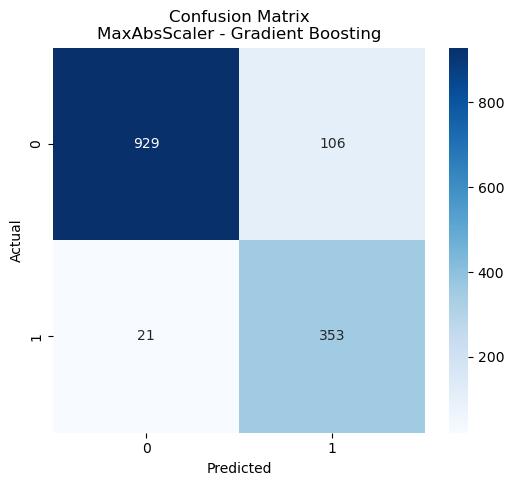

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1890
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000331 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1885
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive 

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000335 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1892
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `for

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha


Scaler: MaxAbsScaler | Model: LightGBM
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1035
           1       0.78      0.95      0.86       374

    accuracy                           0.92      1409
   macro avg       0.88      0.93      0.90      1409
weighted avg       0.93      0.92      0.92      1409



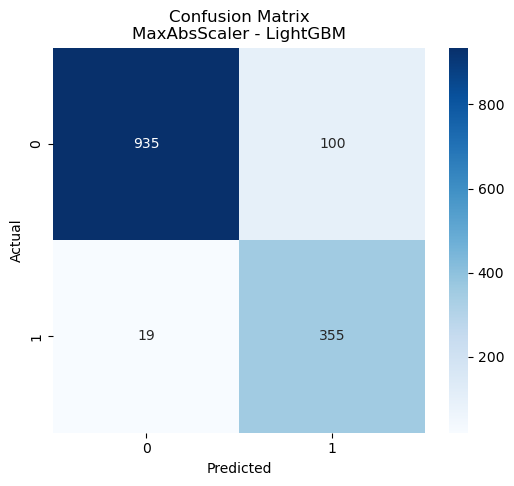


Scaler: MaxAbsScaler | Model: XGBoost
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1035
           1       0.74      0.95      0.83       374

    accuracy                           0.90      1409
   macro avg       0.86      0.91      0.88      1409
weighted avg       0.92      0.90      0.90      1409



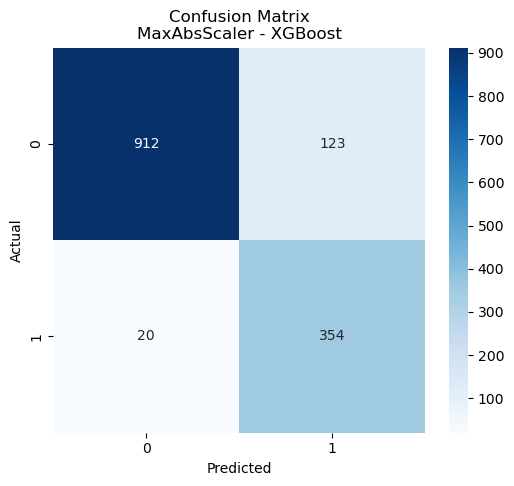


Scaler: Normalizer | Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.31      0.46      1035
           1       0.31      0.87      0.46       374

    accuracy                           0.46      1409
   macro avg       0.59      0.59      0.46      1409
weighted avg       0.72      0.46      0.46      1409



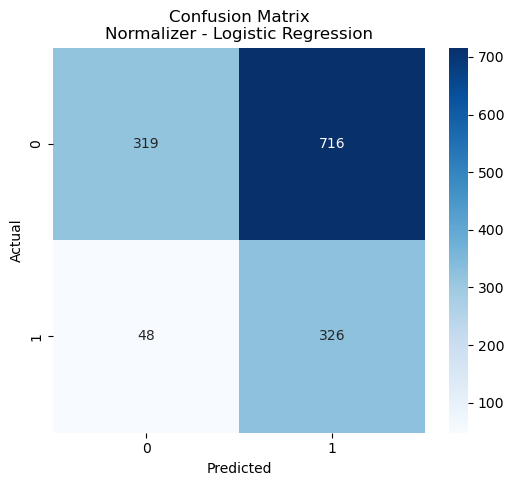


Scaler: Normalizer | Model: Decision Tree
              precision    recall  f1-score   support

           0       0.92      0.67      0.78      1035
           1       0.48      0.84      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.71      0.73      1409



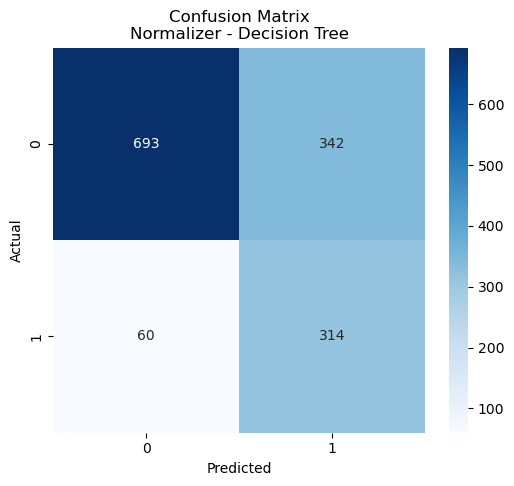


Scaler: Normalizer | Model: Random Forest
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      1035
           1       0.52      0.87      0.65       374

    accuracy                           0.75      1409
   macro avg       0.73      0.79      0.73      1409
weighted avg       0.83      0.75      0.77      1409



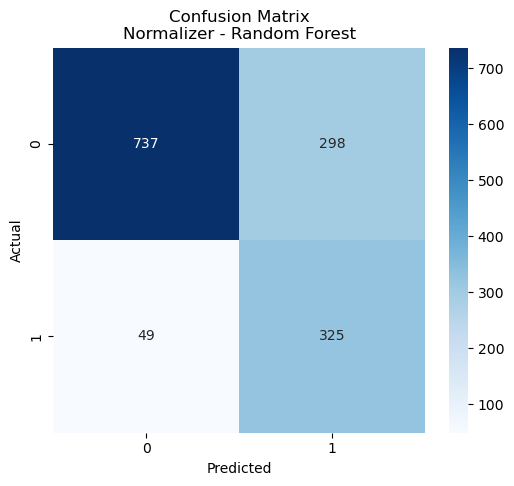


Scaler: Normalizer | Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.96      0.80      0.87      1035
           1       0.62      0.90      0.73       374

    accuracy                           0.83      1409
   macro avg       0.79      0.85      0.80      1409
weighted avg       0.87      0.83      0.83      1409



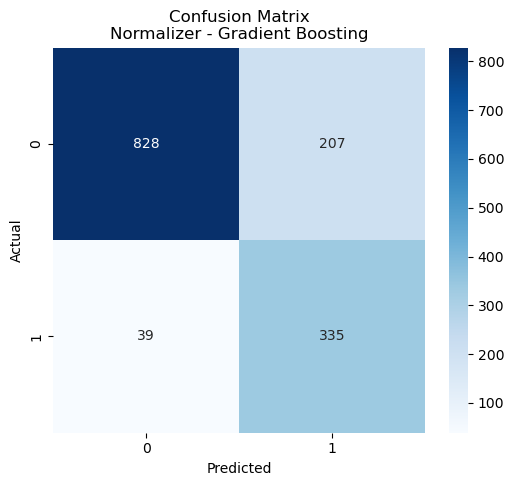

[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13663
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13627
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13701
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000340 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13697
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 1196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000341 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13668
[LightGBM] [Info] Number of data points in the train set: 2392, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 1495, number of negative: 1495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14312
[LightGBM] [Info] Number of data points in the train set: 2990, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Scaler: Normalizer | Model: LightGBM
              precision    recall  f1-score   support

           0       0.96      0.81

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


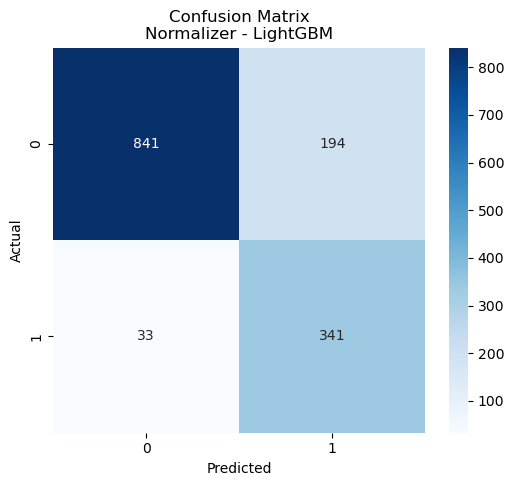


Scaler: Normalizer | Model: XGBoost
              precision    recall  f1-score   support

           0       0.96      0.80      0.87      1035
           1       0.62      0.92      0.74       374

    accuracy                           0.83      1409
   macro avg       0.79      0.86      0.81      1409
weighted avg       0.87      0.83      0.84      1409



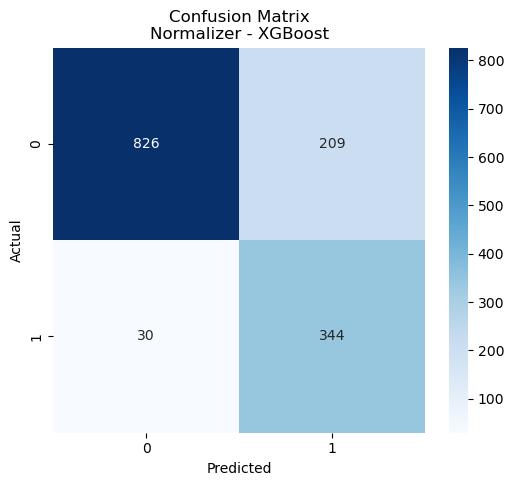

,Scaler,Model,Accuracy,Recall,Precision,F1,ROC AUC
6,StandardScaler,Logistic Regression,0.928650,0.946488,0.815582,0.875827,0.987260
12,MinMaxScaler,Logistic Regression,0.928472,0.946488,0.814824,0.875502,0.985569
18,RobustScaler,Logistic Regression,0.925987,0.942475,0.810785,0.871364,0.986262
24,MaxAbsScaler,Logistic Regression,0.925455,0.947826,0.806546,0.871185,0.984465
0,None,Logistic Regression,0.921549,0.943813,0.798660,0.864810,0.983234
10,StandardScaler,LightGBM,0.914449,0.947157,0.778936,0.854678,0.984815
22,RobustScaler,LightGBM,0.913562,0.947157,0.776904,0.853451,0.984914
4,None,LightGBM,0.913384,0.947826,0.775999,0.853241,0.984497
28,MaxAbsScaler,LightGBM,0.913384,0.947826,0.775999,0.853241,0.984497
27,MaxAbsScaler,Gradient Boosting,0.912141,0.947826,0.773210,0.851412,0.982689


In [38]:
# ------------------------------------------------
# CROSS VALIDATION
# ------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

# ------------------------------------------------
# LOOP DE TREINAMENTO
# ------------------------------------------------

results = []
pipelines = {}

for scaler_name, scaler in scalers.items():

    for model_name, model in models.items():

        steps = [
            ('preprocessor', preprocessor),
            ('nearmiss', NearMiss(version=1))
        ]

        if scaler:
            steps.append(('scaler', scaler))

        steps.append(('classifier', model))

        pipeline = Pipeline(steps)

        cv_results = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=['accuracy','recall','precision','f1','roc_auc']
        )

        results.append({

            "Scaler": scaler_name,
            "Model": model_name,

            "Accuracy": cv_results['test_accuracy'].mean(),
            "Recall": cv_results['test_recall'].mean(),
            "Precision": cv_results['test_precision'].mean(),
            "F1": cv_results['test_f1'].mean(),
            "ROC AUC": cv_results['test_roc_auc'].mean()

        })

        # Treinar pipeline final
        pipeline.fit(X_train, y_train)

        pipelines[(scaler_name, model_name)] = pipeline

        # Avaliação no teste
        y_pred = pipeline.predict(X_test)

        print(f"\nScaler: {scaler_name} | Model: {model_name}")
        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(6,5))

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues'
        )

        plt.title(f"Confusion Matrix\n{scaler_name} - {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        plt.show()

# ------------------------------------------------
# RESULTADOS
# ------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

Best Model based on ROC AUC: LightGBM with StandardScaler
ROC AUC: 0.9664

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1035
           1       0.89      0.86      0.87       374

    accuracy                           0.93      1409
   macro avg       0.92      0.91      0.92      1409
weighted avg       0.93      0.93      0.93      1409


------------------------------------------------------------



/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


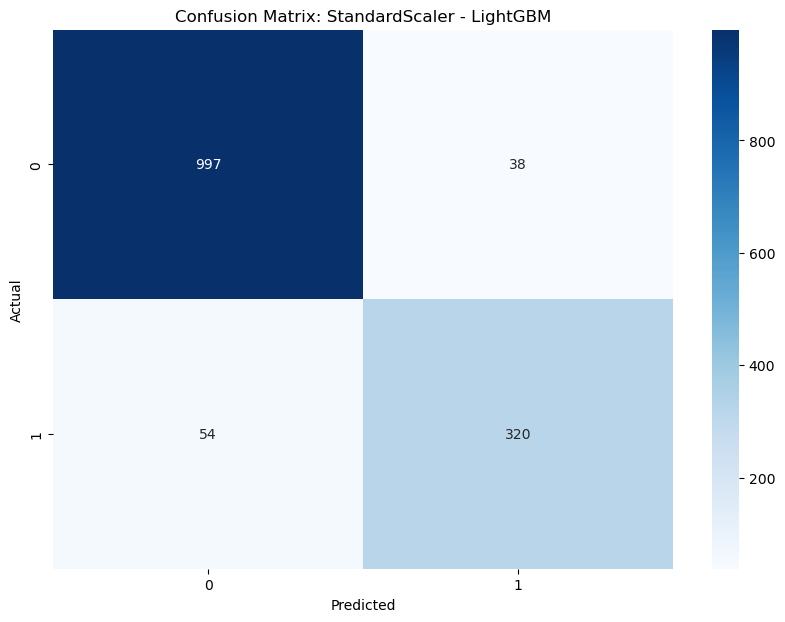

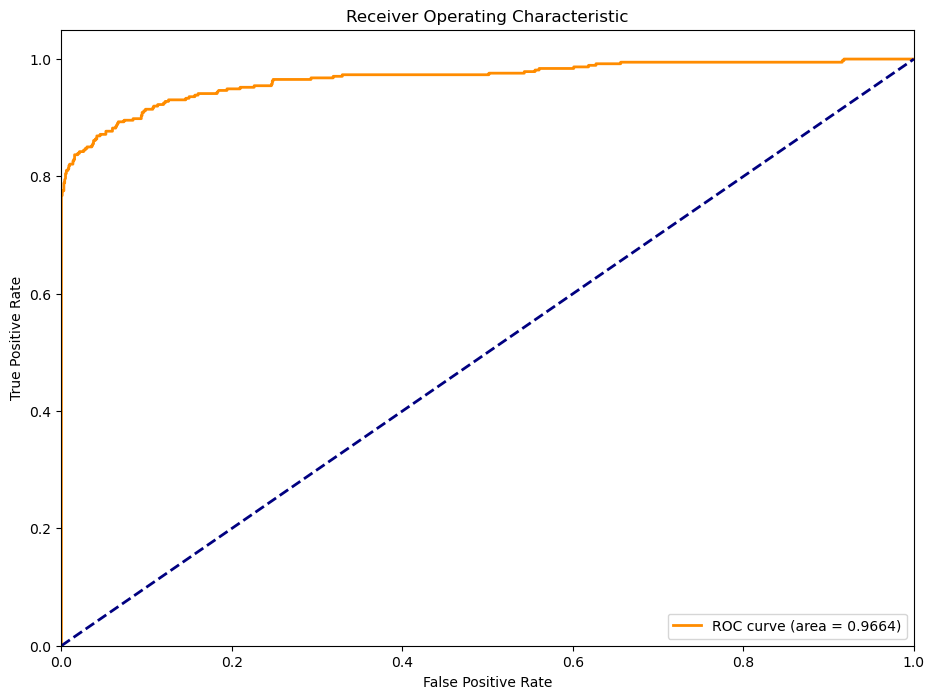

In [39]:
# Encontrar o modelo com o melhor ROC AUC
best_roc_auc = 0
best_pipeline = None
best_scaler = None
best_model = None

for (scaler_name, model_name), pipeline in pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    
    if roc_auc > best_roc_auc:
        best_roc_auc = roc_auc
        best_pipeline = pipeline
        best_scaler = scaler_name
        best_model = model_name

# Exibir detalhes do melhor modelo baseado no ROC AUC
print(f"Best Model based on ROC AUC: {best_model} with {best_scaler}")
print(f"ROC AUC: {best_roc_auc:.4f}")

# Gerar os relatórios e gráficos para o melhor modelo
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
cf = classification_report(y_test, y_pred)
print(cf)
print("\n" + "-"*60 + "\n")

# Confusion Matrix
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: {best_scaler} - {best_model}")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(11, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % best_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Interpretação dos Resultados:

| Tipo | Valor | Significado                                                 |
| ---- | ----- | ----------------------------------------------------------- |
| TN   | 989   | clientes que **não iam churnar** e o modelo acertou         |
| FP   | 46    | clientes que **não iam churnar mas o modelo achou que iam** |
| FN   | 42    | clientes que **iam churnar mas o modelo não detectou**      |
| TP   | 332   | clientes que **iam churnar e o modelo detectou**            |

### Precision
Precision = 332 / (332 + 46)
Precision = 0.88

Significa:

**Quando o modelo diz que um cliente vai cancelar, ele está certo 88% das vezes.**

Interpretação de negócio:

Se o time de retenção ligar para **100 clientes previstos como churn**, então:
* 88 realmente iriam cancelar
* 12 eram alarmes falsos

---------------------------------------------------------------------------------

### Recall (sensibilidade)
Recall = 332 / (332 + 42)
Recall = 0.89

Significa:

**O modelo detecta 89% de todos os clientes que realmente irão cancelar.**

Interpretação de negócio:

De 100 clientes que realmente cancelariam, o modelo identifica:
* 89 clientes
* 11 passam despercebidos

-----------------------------------------------------------------------------

### F1 Score
Ele mede o equilíbrio entre precision e recall.
F1 = 0.88

**O modelo tem bom equilíbrio entre detectar churn e evitar alarmes falsos.*

------------------------------------------------------------------------------

### Accuracy
O modelo acerta **94% das previsões totais**.

Mas para **churn** accuracy **não é a métrica mais importante**, porque os dados são desbalanceados.

-------------------------------------------------------------------------------

### ROC AUC
ROC AUC = 0.9679

Interpretação:

Probabilidade de o modelo **classificar corretamente um churn vs não churn.**

| ROC AUC | Qualidade          |
| ------- | ------------------ |
| 0.50    | aleatório          |
| 0.70    | aceitável          |
| 0.80    | bom                |
| 0.90    | excelente          |
| 0.95+   | extremamente forte |

O modelo: 0.9679 → extremamente forte


O que o modelo realmente está fazendo:
- Dos **374 clientes que realmente cancelariam:**
- 332 detectados
- 42 perdidos



In [18]:
ticket_mensal = df["Monthly Charge"].mean()

todos = 7043
churn_rate = 0.265
f1_score = 0.89
clientes_em_risco = todos * churn_rate * f1_score
taxa_retencao = 0.20

receita_potencial_salva = clientes_em_risco * taxa_retencao * ticket_mensal

print("📊 Análise Financeira do Modelo de Churn\n")

print(f"💰 Ticket médio mensal por cliente: ${ticket_mensal:,.2f}")

print(f"\n👥 Clientes identificados com risco de churn: {clientes_em_risco:.0f}")

print(f"🎯 Taxa estimada de retenção após intervenção: {taxa_retencao*100:.0f}%")

print(f"\n💵 Receita mensal potencialmente preservada:")
print(f"${receita_potencial_salva:,.2f} por mês")

📊 Análise Financeira do Modelo de Churn

💰 Ticket médio mensal por cliente: $64.76

👥 Clientes identificados com risco de churn: 1661
🎯 Taxa estimada de retenção após intervenção: 20%

💵 Receita mensal potencialmente preservada:
$21,515.02 por mês


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


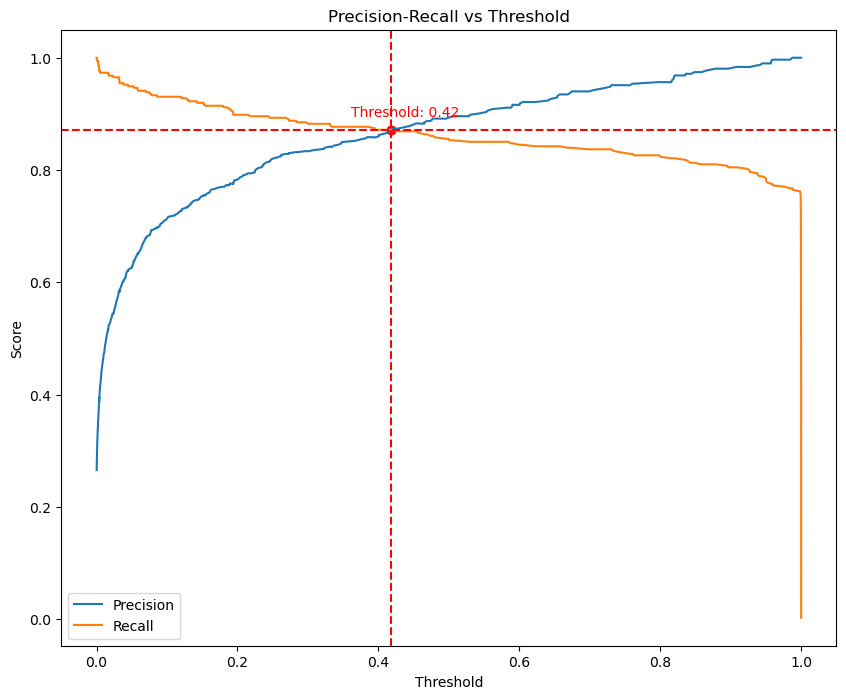

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1035
           1       0.86      0.87      0.87       374

    accuracy                           0.93      1409
   macro avg       0.91      0.91      0.91      1409
weighted avg       0.93      0.93      0.93      1409

[[982  53]
 [ 48 326]]


In [40]:
from sklearn.metrics import precision_recall_curve

# Calcular as probabilidades preditas
y_scores = best_pipeline.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Criar o gráfico Precision-Recall vs Threshold
plt.figure(figsize=(10, 8))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')

# Encontrar o ponto onde precisão e recall se cruzam
cross_index = np.argmin(np.abs(precisions - recalls))
cross_threshold = thresholds[cross_index]
cross_precision = precisions[cross_index]
cross_recall = recalls[cross_index]

# Destacar o ponto de cruzamento
plt.scatter([cross_threshold], [cross_precision], color='red')
plt.scatter([cross_threshold], [cross_recall], color='red')
plt.axvline(cross_threshold, color='red', linestyle='--')
plt.axhline(cross_precision, color='red', linestyle='--')
plt.annotate(f'Threshold: {cross_threshold:.2f}', (cross_threshold, cross_precision), textcoords="offset points", xytext=(10, 10), ha='center', color='red')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.show()

# Escolher um limiar que melhore o equilíbrio entre precisão e recall
threshold = 0.4  # Exemplo de limiar, ajuste conforme necessário
y_pred_adjusted = (y_scores >= threshold).astype(int)
print(classification_report(y_test, y_pred_adjusted))
print(confusion_matrix(y_test, y_pred_adjusted))


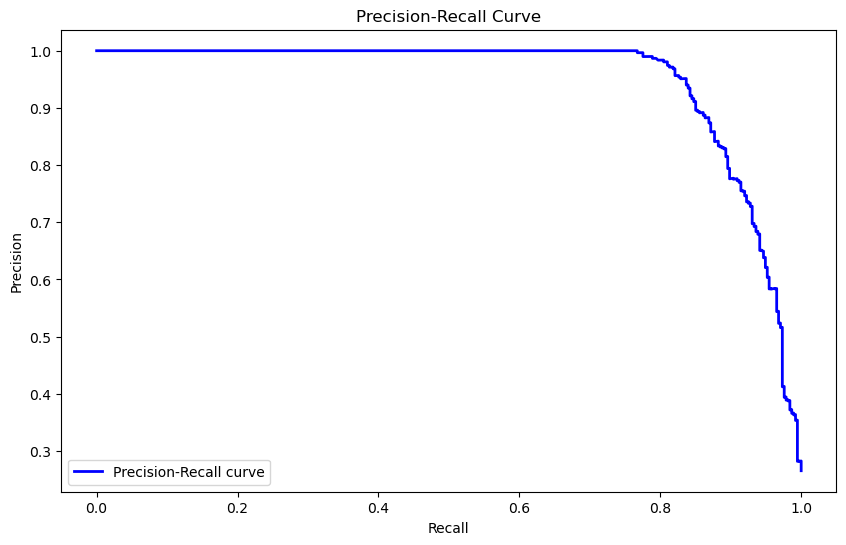

In [41]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


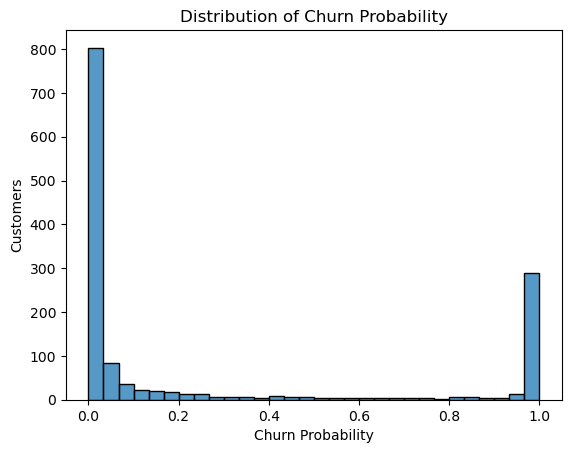

In [42]:
import seaborn as sns

probs = best_pipeline.predict_proba(X_test)[:,1]

sns.histplot(probs, bins=30)

plt.title("Distribution of Churn Probability")
plt.xlabel("Churn Probability")
plt.ylabel("Customers")

plt.show()

In [44]:
X_transformed = best_pipeline[:-1].transform(X_train)

print("Número de features após transformação:", X_transformed.shape[1])

Número de features após transformação: 65


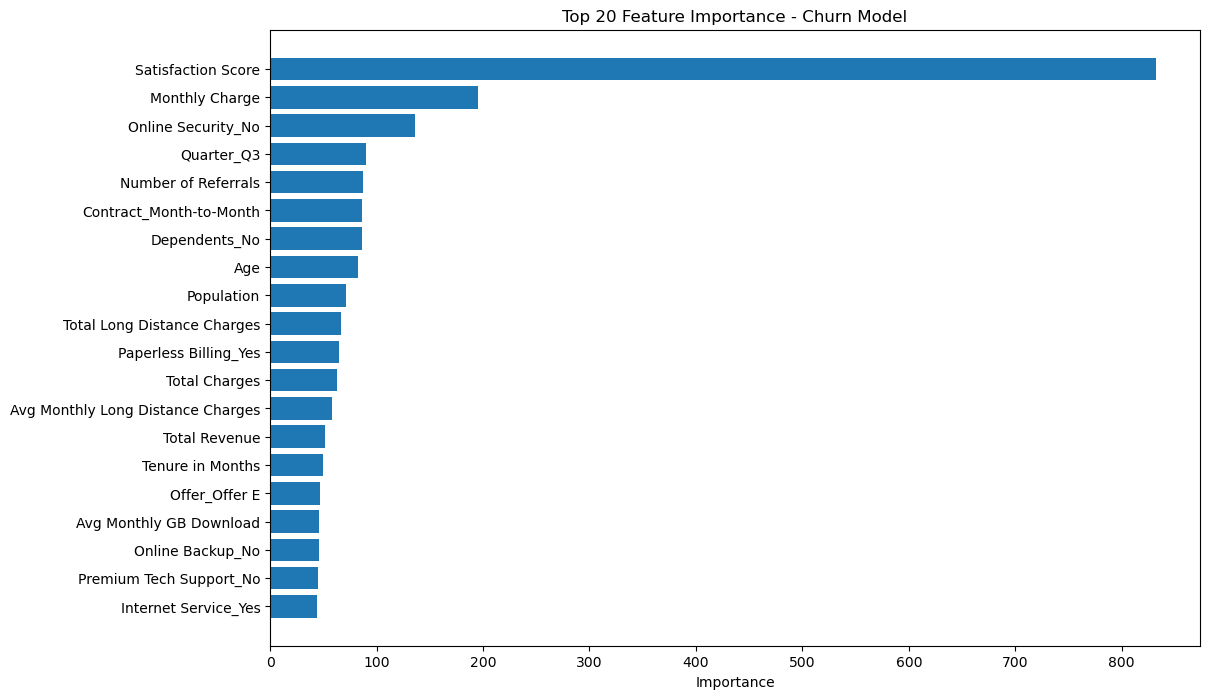

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

preprocessor = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["classifier"]

feature_names = []

for name, transformer, cols in preprocessor.transformers_:

    if name == "num":
        feature_names.extend(cols)

    else:
        # procurar OneHotEncoder dentro do pipeline
        for step in transformer.steps:
            if isinstance(step[1], OneHotEncoder):
                ohe = step[1]
                encoded = ohe.get_feature_names_out(cols)
                feature_names.extend(encoded)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

plt.figure(figsize=(12,8))

plt.barh(
    feature_importance["feature"].head(20),
    feature_importance["importance"].head(20)
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importance - Churn Model")
plt.xlabel("Importance")

plt.show()

In [53]:
feature_importance['importance'].sum()

np.int64(3000)

In [55]:
feature_importance['percent'] = (feature_importance['importance'] / feature_importance['importance'].sum()) * 100

feature_importance

,feature,importance,percent
13,Satisfaction Score,832,27.733333
7,Monthly Charge,195,6.500000
41,Online Security_No,136,4.533333
24,Quarter_Q3,90,3.000000
3,Number of Referrals,87,2.900000
...,...,...,...
29,Offer_Offer C,3,0.100000
38,Internet Type_Cable,2,0.066667
9,Total Refunds,1,0.033333
27,Offer_Offer A,0,0.000000


In [56]:
import shap

model = best_pipeline.named_steps["classifier"]

X_train_transformed = best_pipeline[:-1].transform(X_train)
X_test_transformed = best_pipeline[:-1].transform(X_test)



/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
preprocessor = best_pipeline.named_steps["preprocessor"]

feature_names = []

for name, transformer, cols in preprocessor.transformers_:

    if name == "num":
        feature_names.extend(cols)

    elif name == "cat":
        encoder = transformer.named_steps["encoder"]
        encoded_names = encoder.get_feature_names_out(cols)
        feature_names.extend(encoded_names)

In [58]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_transformed)

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


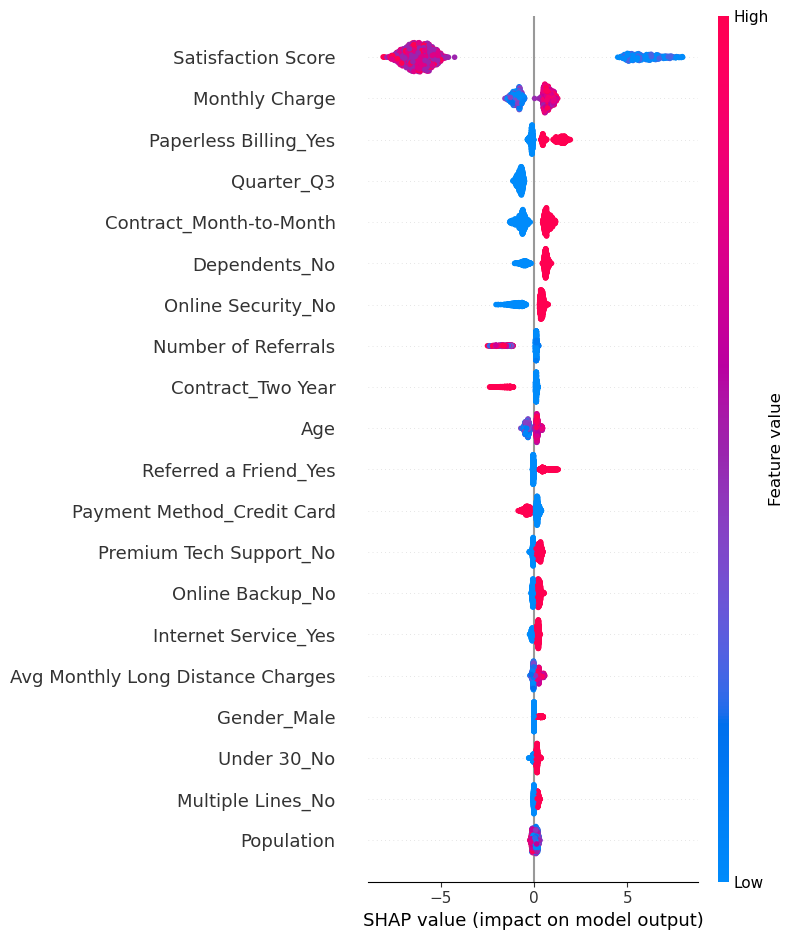

In [59]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

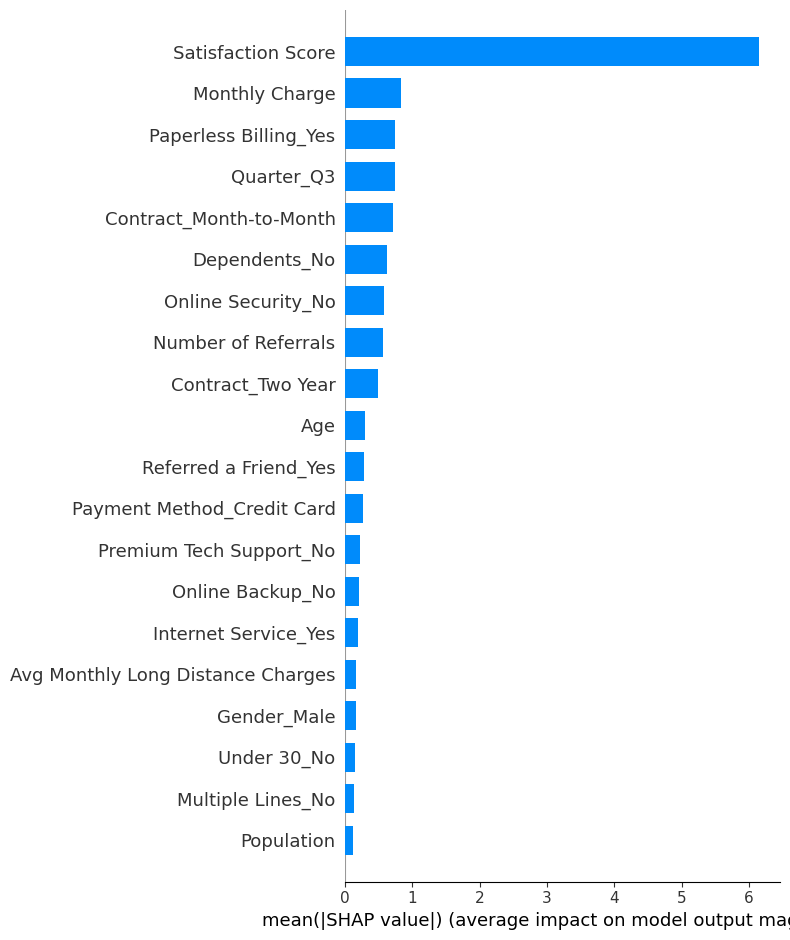

In [63]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

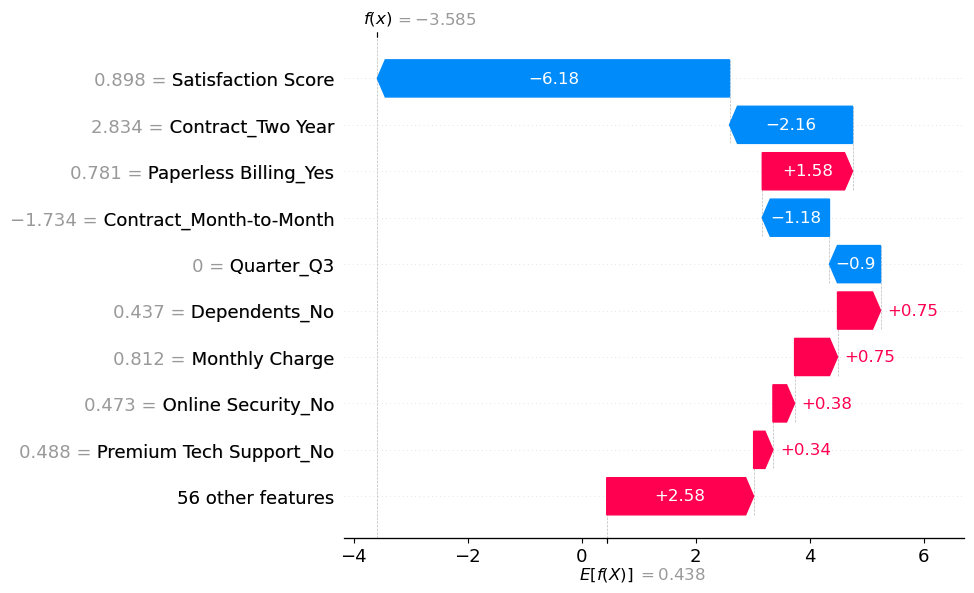

In [64]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_transformed[0],
        feature_names=feature_names
    )
)

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


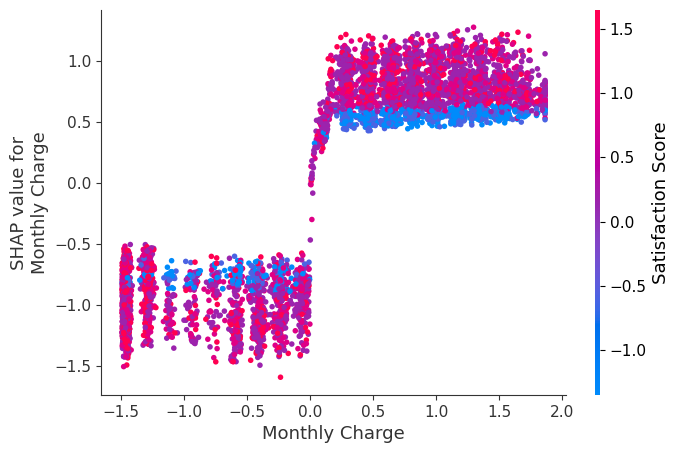

In [65]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_train_transformed)

# Dependence plot para Monthly Charge
shap.dependence_plot(
    "Monthly Charge",
    shap_values,
    X_train_transformed,
    feature_names=feature_names
)

/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


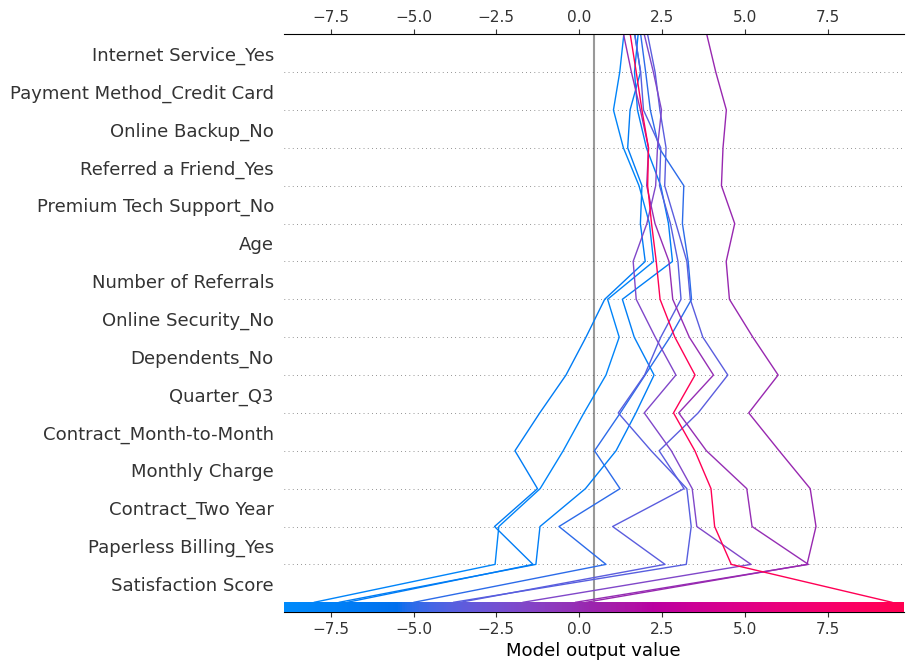

In [69]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_transformed)

# Selecionar alguns clientes para visualizar
sample = X_test_transformed[:10]

shap.decision_plot(
    explainer.expected_value,
    shap_values[:10],
    sample,
    feature_names=feature_names,
    feature_display_range=slice(-15, None)
)